In [1]:
import os
from dotenv import load_dotenv
from typing import TypedDict

from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader

from langchain_groq import ChatGroq

from langgraph.graph import StateGraph, END

load_dotenv()

True

In [2]:
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
DB_PATH = r"C:\Users\user\Desktop\RAG Projects\Legal RAG 1\vector_database"

constitution_db = Chroma(
    persist_directory=DB_PATH,
    embedding_function=embeddings,
    collection_name="legal_knowledge"
)

print("Total chunks:", constitution_db._collection.count())

Total chunks: 787


In [4]:
# chunking function

from langchain_experimental.text_splitter import SemanticChunker
from langchain_text_splitters import RecursiveCharacterTextSplitter
import re


def split_documents(docs, embeddings, debug=False):

    # STEP 1 — STRUCTURE SPLIT (legal headings + statutes)
    structure_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1800,
        chunk_overlap=250,
        separators=[
            r"\n\s*ISSUE",
            r"\n\s*FACTS",
            r"\n\s*BACKGROUND",
            r"\n\s*ARGUMENT",
            r"\n\s*ANALYSIS",
            r"\n\s*HOLDING",
            r"\n\s*ORDER",
            r"\n\s*JUDGMENT",
            r"\n\s*RELIEF",

            # statute references
            r"\n\s*Article\s+\d+",
            r"\n\s*Section\s+\d+",

            # numbered headings
            r"\n\s*\d+\.",
            r"\n\s*\(\d+\)",

            # paragraph breaks
            "\n\n",
            "\n",
            " "
        ],
        is_separator_regex=True
    )

    structured_docs = structure_splitter.split_documents(docs)

    if debug:
        print("\n--- STRUCTURE SPLIT SAMPLE ---")
        for i, d in enumerate(structured_docs[:3]):
            print(f"\nChunk {i}\n", d.page_content[:400])

    # STEP 2 — SEMANTIC SPLIT (topic boundary detection)
    try:
        semantic_splitter = SemanticChunker(
            embeddings
        )

        semantic_docs = semantic_splitter.split_documents(structured_docs)

    except Exception:
        # fallback if semantic splitting fails
        semantic_docs = structured_docs

    if debug:
        print("\n--- SEMANTIC SPLIT SAMPLE ---")
        for i, d in enumerate(semantic_docs[:3]):
            print(f"\nChunk {i}\n", d.page_content[:400])

    # STEP 3 — FINAL SIZE CONTROL
    final_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1500,
        chunk_overlap=250
    )

    final_docs = final_splitter.split_documents(semantic_docs)

    if debug:
        print("\n--- FINAL CHUNK SAMPLE ---")
        for i, d in enumerate(final_docs[:5]):
            print(f"\nChunk {i}\n", d.page_content[:400])

    return final_docs

In [5]:
def load_uploaded_document(file_path):

    loader = PyPDFLoader(file_path)
    docs = loader.load()

    chunks = split_documents(docs, embeddings)

    temp_doc_db = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings
    )

    print("Uploaded document indexed:", len(chunks))

In [6]:
def retrieve_legal_docs(query, k=5):

    docs = constitution_db.similarity_search(
        f"query: {query}",
        k=k
    )

    return docs

In [7]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def retrieve_document_docs(query, k=15):

    if temp_doc_db is None:
        return []

    docs = temp_doc_db.similarity_search(query, k=k)

    pairs = [[query, d.page_content] for d in docs]

    scores = reranker.predict(pairs)

    ranked = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)

    return [doc for doc,_ in ranked[:5]]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [9]:
class LegalState(TypedDict):

    question: str

    strategy: str

    legal_context: str

    document_context: str

    answer: str

In [10]:
def strategist_agent(state: LegalState):

    question = state["question"]

    prompt = f"""
You are a legal strategist.

Determine how to answer the question.

Decide whether the answer requires:

1. Indian law knowledge base
2. Uploaded document
3. Both

Question:
{question}

Provide a short reasoning plan.
"""

    response = llm.invoke(prompt)

    return {"strategy": response.content}

In [11]:
def legal_research_agent(state: LegalState):

    docs = retrieve_legal_docs(state["question"])

    context = "\n\n".join([d.page_content for d in docs])

    return {"legal_context": context}

In [12]:
def document_research_agent(state: LegalState):

    docs = retrieve_document_docs(state["question"], k=20)

    context = "\n\n".join([d.page_content for d in docs])

    return {"document_context": context}

In [13]:
def advisor_agent(state: LegalState):

    question = state["question"]

    legal_context = state["legal_context"]

    document_context = state["document_context"]

    prompt = f"""
You are an expert Indian legal advisor.

Answer the user's question using the provided context.

Only cite legal provisions if they appear in the provided context.
Do not invent constitutional references.

LEGAL CONTEXT:
{legal_context}

DOCUMENT CONTEXT:
{document_context}

QUESTION:
{question}

Provide a clear explanation.
"""

    response = llm.invoke(prompt)

    return {"answer": response.content}

In [14]:
workflow = StateGraph(LegalState)

workflow.add_node("strategist", strategist_agent)
workflow.add_node("legal_research", legal_research_agent)
workflow.add_node("document_research", document_research_agent)
workflow.add_node("advisor", advisor_agent)

# entry
workflow.set_entry_point("strategist")

# branching
workflow.add_edge("strategist", "legal_research")
workflow.add_edge("strategist", "document_research")

# merge
workflow.add_edge("legal_research", "advisor")
workflow.add_edge("document_research", "advisor")

workflow.add_edge("advisor", END)

app = workflow.compile()

In [15]:
legal_graph = workflow.compile()

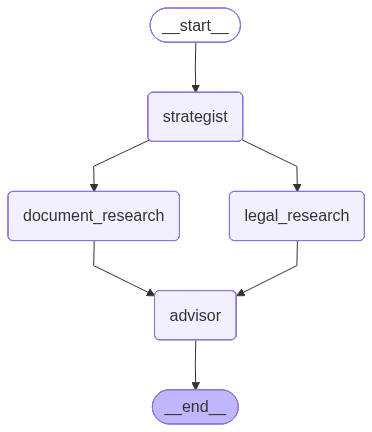

In [16]:
from IPython.display import Image, display

display(Image(legal_graph.get_graph().draw_mermaid_png()))

In [17]:
def legal_agentic_rag(question):

    result = legal_graph.invoke({
        "question": question
    })

    return result["answer"]

In [18]:
print(
    legal_agentic_rag(
        "If a state law conflicts with a central law in India, which one prevails?"
    )
)

NameError: name 'temp_doc_db' is not defined

In [ ]:
file_path = r'C:\Users\user\Desktop\RAG Projects\Legal RAG 1\data\Mrs_Vandana_Dhirani_vs_Mrs_Arti_Kirloskar_on_27_July_2023.PDF'
load_uploaded_document(file_path)

print(
    legal_agentic_rag(
        "What is the CS DJ number of this suit?"
    )
)

Uploaded document indexed: 110
The CS DJ number of this suit is 588/2021. 

This can be inferred from the multiple references to "CS DJ NO.588/2021" throughout the provided document context, which appears to be a court judgment. The "CS DJ" likely stands for "Civil Suit District Judge," and the number "588/2021" is the specific case number assigned to this suit. The repetition of this number in different parts of the document context confirms that it is indeed the CS DJ number for the suit between Mrs. Vandana Dhirani and Mrs. Arti Kirloskar.


In [ ]:
print(
    legal_agentic_rag(
        "What was the result of the suit announced on 27.07.2023?"
    )
)

The result of the suit announced on 27.07.2023, in the case of Mrs. Vandana Dhirani vs Mrs. Arti Kirloskar, was decided in favor of the plaintiff, Mrs. Vandana Dhirani, and against the defendant, Mrs. Arti Kirloskar. 

The court concluded that the plaintiff had offered possession of the suit property to the defendant via email dated 28.02.2020, and since the lease was to commence from 01.03.2020 and the rent for the month of March had been paid, the constructive possession of the suit property had vested with the defendant.

This decision was made based on the analysis of the email exchanges between the parties, including the plaintiff's offer of possession and the defendant's acknowledgment of the arrangement. The court found that the defendant had failed to discharge the onus of proving that the plaintiff had not offered possession, and therefore, the issue was decided in favor of the plaintiff.

It is worth noting that this decision is based on the specific facts and circumstances o

In [ ]:
# Path to your uploaded document
doc_path = r"C:/Users/user/Desktop/RAG Projects/Legal RAG 1/data/Mrs_Vandana_Dhirani_vs_Mrs_Arti_Kirloskar_on_27_July_2023.PDF"

# Load document into temporary vector store
load_uploaded_document(doc_path)

doc_tests = [
    ("Who is the plaintiff in this case?", "Vandana Dhirani", "Check entity extraction."),
    ("What is the CS DJ number of this suit?", "588/2021", "Check specific document metadata extraction."),
    ("What was the result of the suit announced on 27.07.2023?", "Dismissed", "Check case outcome accuracy."),
    ("What was Issue No. 8 about?", "Interest", "Check specific legal issue identification."),
    ("Who was the presiding judge in the Saket Courts for this case?", "Navjeet Budhiraja", "Check judge name extraction."),
    ("Did the court allow the recovery of arrears of rent?", "not found entitled", "Check core judgment findings."),
    ("At what floor is the property C-99 located?", "4th Floor", "Check property detail extraction."),
    ("What was the date of institution of this suit?", "31.08.2021", "Check procedural dates."),
    ("What reason did the defendant give for not paying rent (Issue 4)?", "force majeure", "Check defense arguments (Covid / Force Majeure)."),
    ("Was a decree sheet ordered to be prepared?", "Decree sheet be prepared", "Check final court directions.")
]

print("\n--- RUNNING DOCUMENT-SPECIFIC TESTS ---\n")

for i, (q, key, reason) in enumerate(doc_tests):

    res = legal_agentic_rag(q)

    # INITIAL PASS CHECK
    status = "PASS" if key.lower() in res.lower() else "FAIL"

    # FLEXIBLE PASS CHECK (Handling synonyms / phrasing)
    if status == "FAIL":
        if "dismiss" in res.lower() and key.lower() == "dismissed":
            status = "PASS (Synonym)"
        elif "not entitled" in res.lower() and key.lower() == "not found entitled":
            status = "PASS (Synonym)"
        elif "saket" in res.lower() and key.lower() == "navjeet budhiraja":
            status = "FAIL (Partial Match)"

    print(f"DOC TEST #{i+1}")
    print(f"Question: {q}")
    print(f"AI Answer: {res.strip()}")
    print(f"Evaluation: {status} (Target Key: {key})")
    print(f"Reasoning: {reason}")
    print("-" * 60)

Uploaded document indexed: 120

--- RUNNING DOCUMENT-SPECIFIC TESTS ---

DOC TEST #1
Question: Who is the plaintiff in this case?
AI Answer: Unfortunately, the provided context does not mention the plaintiff in the case. The context appears to be related to the Constitution of India, specifically various articles and provisions. However, it does not provide any information about a specific case or the parties involved in it, including the plaintiff.

To determine the plaintiff in a case, we would typically need information about the case itself, such as the parties involved, the nature of the dispute, and the court proceedings. Since this information is not provided in the context, it is not possible to identify the plaintiff in this case.
Evaluation: FAIL (Target Key: Vandana Dhirani)
Reasoning: Check entity extraction.
------------------------------------------------------------
DOC TEST #2
Question: What is the CS DJ number of this suit?
AI Answer: There is no information provided i

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kbn58qpqfjgstzyswyfty5g2` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99635, Requested 504. Please try again in 2m0.095999999s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [ ]:
# Set of general legal knowledge questions with expected keywords and evaluation notes
general_tests = [
    ("What conditions justify issuing a Writ of Habeas Corpus?", "Article 32", "Tests knowledge of constitutional remedies and fundamental rights."),
    ("What punishment applies for drunk driving under the Motor Vehicles Act?", "Section 185", "Checks whether the system retrieves specific statutory provisions."),
    ("Does the Indian Constitution recognize a right to privacy?", "Puttaswamy", "Evaluates recognition of landmark Supreme Court judgments."),
    ("How many individuals can the President nominate to the Rajya Sabha?", "12", "Validates factual constitutional knowledge."),
    ("Which constitutional article establishes the Finance Commission?", "Article 280", "Confirms awareness of administrative constitutional provisions."),
    ("Is it possible to punish someone twice for the same offense?", "Double Jeopardy", "Tests understanding of the Article 20(2) protection."),
    ("What is the minimum age required to become the Prime Minister of India?", "25", "Checks basic constitutional eligibility criteria."),
    ("Does the Right to Property remain a Fundamental Right in India?", "300A", "Tests knowledge of its shift after the 44th Constitutional Amendment."),
    ("Which article of the Constitution abolishes untouchability?", "Article 17", "Assesses knowledge of core fundamental rights provisions."),
    ("Can Fundamental Rights be suspended during a national emergency?", "Article 359", "Evaluates understanding of emergency provisions in the Constitution.")
]

print("--- EXECUTING GENERAL KNOWLEDGE BASE TESTS ---\n")

for i, (question, keyword, explanation) in enumerate(general_tests):

    # legal_agentic_rag runs the LangGraph agentic workflow
    response = legal_agentic_rag(question)

    result = "PASS" if keyword.lower() in response.lower() else "FAIL"

    print(f"TEST #{i+1}")
    print(f"Question: {question}")
    print(f"AI Answer: {response.strip()}")
    print(f"Evaluation: {result} (Expected Keyword: {keyword})")
    print(f"Purpose: {explanation}")
    print("-" * 50)

--- EXECUTING GENERAL KNOWLEDGE BASE TESTS ---



RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kbn58qpqfjgstzyswyfty5g2` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99983, Requested 2472. Please try again in 35m21.12s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}